# Comparison of anisotropic fits

This notebook compares the saved `cf_ca_aniso` results without rerunning the scattering fits. It automatically discovers available concentrations, overlays measured and fitted curves, checks fit/data ratios, and summarizes the fitted radial width and anisotropy.

In [1]:
from pathlib import Path
import csv
import re
from datetime import datetime

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, DrawingArea
from matplotlib.patches import Ellipse
import numpy as np

import cf_tools as cf

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200, 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.alpha': 0.22,
})
OUTPUT_DIR = Path('output/ca_aniso')

# Keep these switches identical to the settings used in cf_ca_aniso.ipynb.
K_DISTRIBUTION = 'gamma_radial'  # 'gaussian_radial' or 'gamma_radial'
STRETCH_MODEL = 'full_geom'  # 'spectrum' or 'full_geom'
DISTRIBUTION_UPPER_QUANTILE = 0.99999  # extend P(k) until the upper tail is visually negligible
ELLIPSE_COUNT = 7
ELLIPSE_LAMBDA_ENDPOINTS = (1.0, 2.5)
CHI_SQUARE_ERROR_FLOOR = 0.04
FALLBACK_FITTED_PARAMETER_COUNT = 4  # scale, k_eff, r_sigma_k, stretch_ratio
if K_DISTRIBUTION not in {'gaussian_radial', 'gamma_radial'}:
    raise ValueError('K_DISTRIBUTION must be gaussian_radial or gamma_radial')
if STRETCH_MODEL not in {'spectrum', 'full_geom'}:
    raise ValueError('STRETCH_MODEL must be spectrum or full_geom')
if int(ELLIPSE_COUNT) < 1:
    raise ValueError('ELLIPSE_COUNT must be at least 1')
if len(ELLIPSE_LAMBDA_ENDPOINTS) != 2 or not (0 < ELLIPSE_LAMBDA_ENDPOINTS[0] < ELLIPSE_LAMBDA_ENDPOINTS[1]):
    raise ValueError('ELLIPSE_LAMBDA_ENDPOINTS must be two increasing positive values')

FIT_GUIDANCE_TAG = f'unguided_{K_DISTRIBUTION}_{STRETCH_MODEL}_OH2'
PARAMETER_SUFFIX = f'_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_parameters.csv'
CURVE_SUFFIX = f'_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_curve.csv'
COMPARE_TAG = f'{K_DISTRIBUTION}_{STRETCH_MODEL}'
COMPARE_OUTPUT_DIR = OUTPUT_DIR / 'comparison' / COMPARE_TAG
COMPARE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'[comparison mode] k_distribution={K_DISTRIBUTION}, stretch={STRETCH_MODEL}')


[comparison mode] k_distribution=gamma_radial, stretch=full_geom


In [2]:
def concentration_from_tag(tag):
    if tag == 'ca_D2O':
        return 0.0
    match = re.fullmatch(r'ca_(\d+(?:\.\d+)?)mM', tag)
    if match is None:
        raise ValueError(f'Cannot parse concentration from {tag!r}')
    return float(match.group(1))

def load_parameter_csv(path):
    with path.open(newline='', encoding='utf-8') as handle:
        return {row['name']: float(row['value']) for row in csv.DictReader(handle)}

candidates = []
for parameter_path in OUTPUT_DIR.glob(f'ca_*{PARAMETER_SUFFIX}'):
    tag = parameter_path.name[:-len(PARAMETER_SUFFIX)]
    curve_path = OUTPUT_DIR / f'{tag}{CURVE_SUFFIX}'
    if not curve_path.exists():
        print(f'[skip] missing curve for {parameter_path.name}')
        continue
    parameters = load_parameter_csv(parameter_path)
    concentration = parameters.get('salt_concentration_mM', concentration_from_tag(tag))
    curve = np.loadtxt(curve_path, delimiter=',', skiprows=1)
    candidates.append({
        'tag': tag, 'concentration_mM': concentration, 'parameters': parameters,
        'curve': curve, 'parameter_path': parameter_path, 'curve_path': curve_path,
        'complete_pair_mtime': min(parameter_path.stat().st_mtime, curve_path.stat().st_mtime),
    })
newest_by_concentration = {}
for candidate in candidates:
    concentration = float(candidate['concentration_mM'])
    previous = newest_by_concentration.get(concentration)
    if previous is None or candidate['complete_pair_mtime'] > previous['complete_pair_mtime']:
        newest_by_concentration[concentration] = candidate
results = sorted(newest_by_concentration.values(), key=lambda result: result['concentration_mM'])
if not results:
    raise FileNotFoundError(f'No paired fit outputs found in {OUTPUT_DIR}')
print('[loaded]', ', '.join('D2O' if r['concentration_mM'] == 0 else f"{r['concentration_mM']:g} mM" for r in results))
for result in results:
    modified = datetime.fromtimestamp(result['complete_pair_mtime']).isoformat(sep=' ', timespec='seconds')
    print(f"[fit source] {result['parameter_path'].name} | complete pair modified {modified}")


[loaded] D2O, 1 mM, 10 mM, 24 mM, 40 mM, 55 mM, 70 mM, 100 mM
[fit source] ca_0mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 14:59:49
[fit source] ca_1mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:01:35
[fit source] ca_10mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:03:02
[fit source] ca_24mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:05:06
[fit source] ca_40mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:10:18
[fit source] ca_55mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:12:26
[fit source] ca_70mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:13:52
[f

## Fitted values

The wavelength is $2\pi/\langle k\rangle$, `r_sigma_k` is the relative radial width, and `stretch_ratio` is the fitted affine anisotropy.

In [3]:
summary_rows = []
for result in results:
    p = result['parameters']
    q_curve, observed, error, fitted = result['curve'].T[:4]
    effective_error = np.maximum(error, CHI_SQUARE_ERROR_FLOOR*np.abs(observed))
    data_chi_square = float(np.sum(((fitted-observed)/effective_error)**2))
    n_fitted = int(round(p.get('n_fitted_parameters', FALLBACK_FITTED_PARAMETER_COUNT)))
    degrees_of_freedom = int(observed.size-n_fitted)
    reduced_chi_square = data_chi_square/degrees_of_freedom if degrees_of_freedom > 0 else np.nan
    summary_rows.append({
        'concentration_mM': result['concentration_mM'],
        'k_eff_A^-1': p['k_eff'],
        'mean_k_A^-1': p['mean_k'],
        'wavelength_A': p.get('feature_wavelength_A', 2*np.pi/p['mean_k']),
        'r_sigma_k': p['r_sigma_k'],
        'stretch_ratio': p['stretch_ratio'],
        'scale': p.get('scale', np.nan),
        'chi_square_data': data_chi_square,
        'degrees_of_freedom': degrees_of_freedom,
        'reduced_chi_square_data': reduced_chi_square,
    })
columns = tuple(summary_rows[0])
print('  '.join(f'{name:>18s}' for name in columns))
for row in summary_rows:
    print('  '.join(f'{row[name]:18.7g}' for name in columns))
with (COMPARE_OUTPUT_DIR / 'ca_fit_parameter_comparison.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=columns); writer.writeheader(); writer.writerows(summary_rows)


  concentration_mM          k_eff_A^-1         mean_k_A^-1        wavelength_A           r_sigma_k       stretch_ratio               scale     chi_square_data  degrees_of_freedom  reduced_chi_square_data
                 0          0.05241129          0.05173715            119.8823           0.1619569            1.213054            12.38148            62.88621                 150           0.4192414
                 1          0.05234021          0.05167959            120.0451           0.1604039            1.260462            12.28619            56.48686                 150           0.3765791
                10          0.04986365          0.04913848            126.0073           0.1724326            1.410754            12.95518            72.72601                 150           0.4848401
                24            0.049496           0.0480261            126.9433           0.2492976            1.550237            12.77408            91.31233                 150           0.6087489


## Scattering curves and fit quality

Curves are offset vertically for visibility. The lower panel shows the unshifted fitted-to-observed ratio.

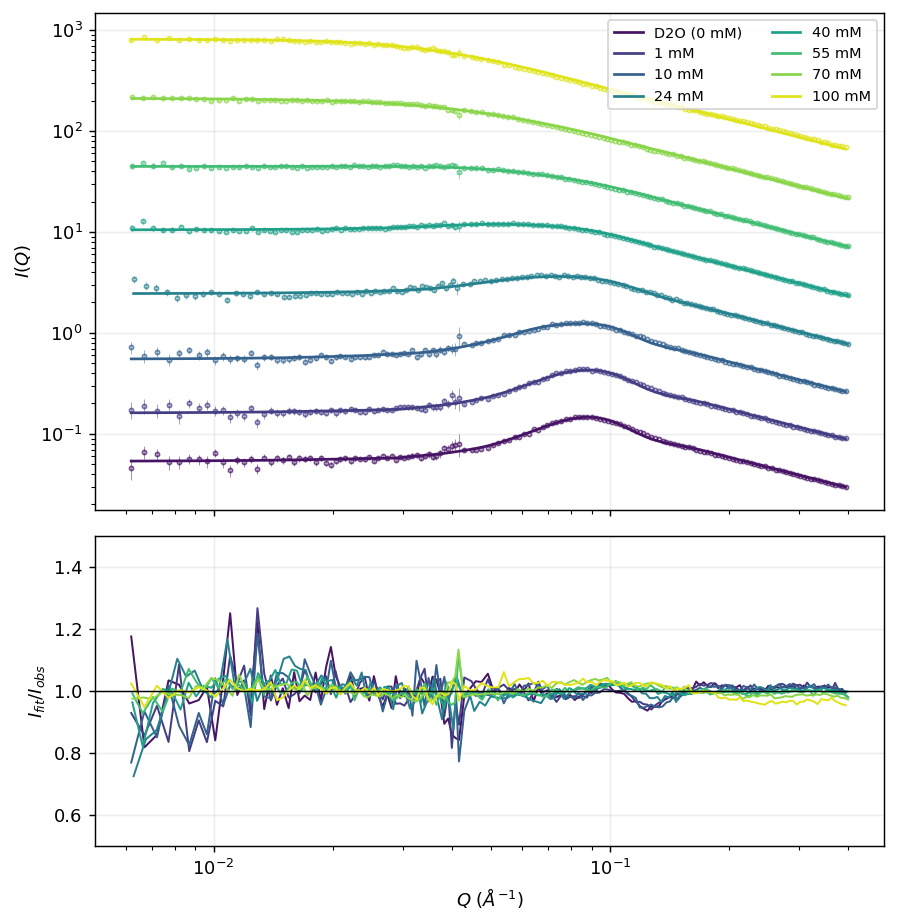

[saved] output\ca_aniso\comparison\gamma_radial_full_geom\ca_fit_curve_comparison.png


In [4]:
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(results)))
fig, axes = plt.subplots(2, 1, figsize=(7.0, 7.2), sharex=True, gridspec_kw={'height_ratios': [1.6, 1.0]})
for index, (result, color) in enumerate(zip(results, colors)):
    q, observed, error, fitted, ratio = result['curve'].T[:5]
    offset = 3.0**index
    concentration = result['concentration_mM']
    label = 'D2O (0 mM)' if concentration == 0 else f'{concentration:g} mM'
    axes[0].errorbar(q, observed*offset, yerr=error*offset, fmt='o', ms=2.2, lw=0.35, color=color, markerfacecolor='none', alpha=0.75)
    axes[0].plot(q, fitted*offset, color=color, lw=1.5, label=label)
    axes[1].semilogx(q, ratio, color=color, lw=1.1, label=label)
axes[0].set(xscale='log', yscale='log', ylabel=r'$I(Q)$')
axes[0].legend(fontsize=8, ncol=2)
axes[1].axhline(1.0, color='black', lw=0.8)
axes[1].set(xlabel=r'$Q$ ($\AA^{-1}$)', ylabel=r'$I_{fit}/I_{obs}$')
axes[1].set_ylim(0.5, 1.5)
fig.tight_layout()
curve_figure = COMPARE_OUTPUT_DIR / 'ca_fit_curve_comparison.png'
fig.savefig(curve_figure, bbox_inches='tight')
plt.show()
print('[saved]', curve_figure)


## Salt dependence of fitted parameters

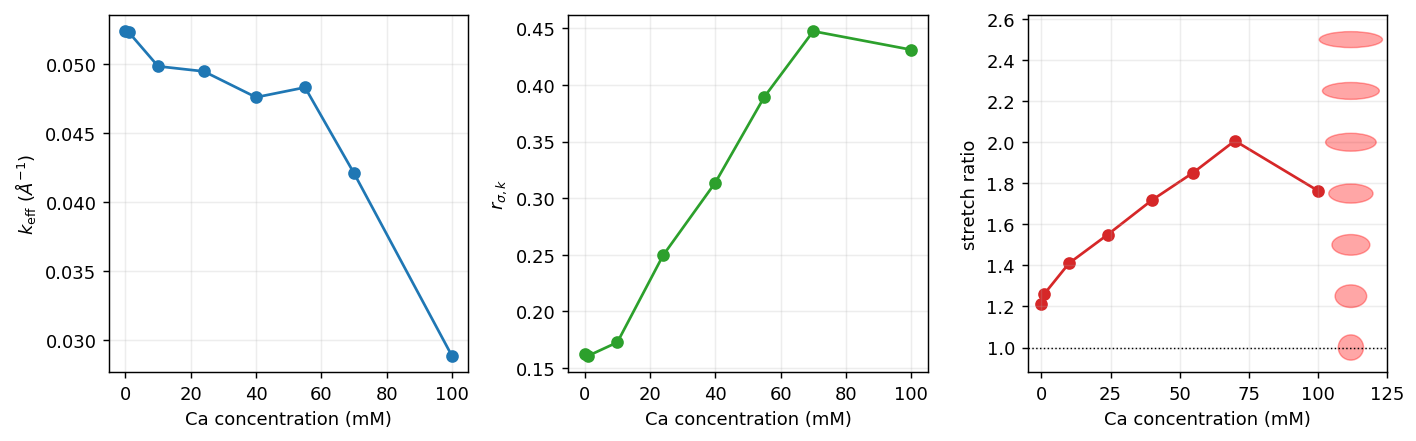

[saved] output\ca_aniso\comparison\gamma_radial_full_geom\ca_fit_parameter_trends.png


In [5]:
concentration = np.asarray([row['concentration_mM'] for row in summary_rows])
k_eff = np.asarray([row['k_eff_A^-1'] for row in summary_rows])
width = np.asarray([row['r_sigma_k'] for row in summary_rows])
stretch = np.asarray([row['stretch_ratio'] for row in summary_rows])
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.5))
axes[0].plot(concentration, k_eff, 'o-', color='C0')
axes[0].set(xlabel='Ca concentration (mM)', ylabel=r'$k_{\rm eff}$ ($\AA^{-1}$)')
axes[1].plot(concentration, width, 'o-', color='C2')
axes[1].set(xlabel='Ca concentration (mM)', ylabel=r'$r_{\sigma,k}$')
axes[2].plot(concentration, stretch, 'o-', color='C3', zorder=1)
ellipse_scale = 14.0
concentration_span = max(float(np.ptp(concentration)), 1.0)
ellipse_x = float(np.max(concentration)) + 0.12*concentration_span
ellipse_lambda = np.linspace(*ELLIPSE_LAMBDA_ENDPOINTS, int(ELLIPSE_COUNT))
ellipse_colors = plt.cm.viridis(np.linspace(0.05, 0.95, ellipse_lambda.size))
for lambda_parallel, color in zip(ellipse_lambda, ellipse_colors):
    color="r"
    lambda_perp = lambda_parallel**(-0.5)
    ellipse_width = ellipse_scale*lambda_parallel
    ellipse_height = ellipse_scale*lambda_perp
    drawing = DrawingArea(ellipse_width, ellipse_height, 0, 0)
    drawing.add_artist(Ellipse(
        (0.5*ellipse_width, 0.5*ellipse_height),
        width=ellipse_width, height=ellipse_height,
        facecolor=color, edgecolor=color, alpha=0.35, lw=0.8,
    ))
    axes[2].add_artist(AnnotationBbox(
        drawing, (ellipse_x, lambda_parallel),
        frameon=False, pad=0.0, box_alignment=(0.5, 0.5), zorder=2,
    ))
# axes[2].axhspan(0.8, 1.5, color='C3', alpha=0.07, label='fit bounds')
axes[2].axhline(1.0, color='black', lw=0.8, ls=':')
axes[2].set(xlabel='Ca concentration (mM)', ylabel='stretch ratio')
axes[2].set_xlim(
    float(np.min(concentration)) - 0.05*concentration_span,
    float(np.max(concentration)) + 0.25*concentration_span,
)
stretch_axis_values = np.concatenate((stretch, ellipse_lambda, [1.0]))
stretch_axis_span = max(float(np.ptp(stretch_axis_values)), 0.1)
axes[2].set_ylim(
    float(np.min(stretch_axis_values)) - 0.08*stretch_axis_span,
    float(np.max(stretch_axis_values)) + 0.08*stretch_axis_span,
)
fig.tight_layout()
parameter_figure = COMPARE_OUTPUT_DIR / 'ca_fit_parameter_trends.png'
fig.savefig(parameter_figure, bbox_inches='tight')
plt.show()
print('[saved]', parameter_figure)


## Fitted radial $k$ distributions

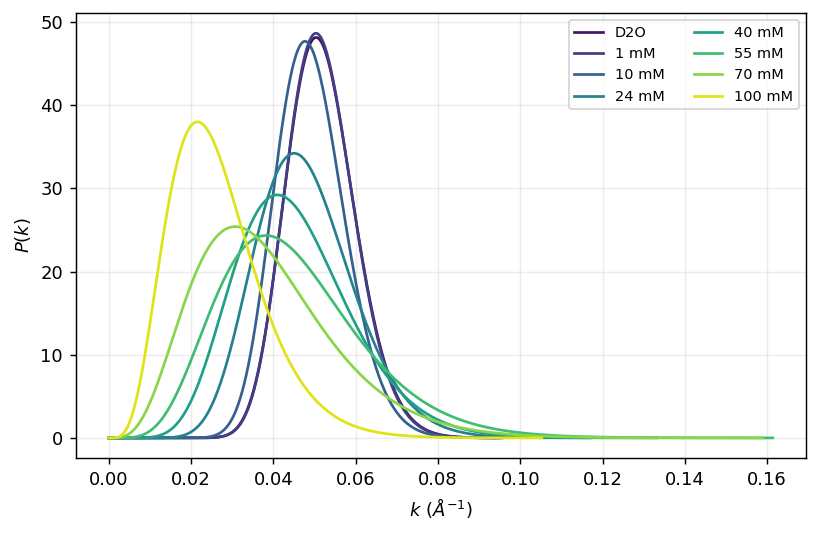

[saved] output\ca_aniso\comparison\gamma_radial_full_geom\ca_k_distribution_comparison.png


In [6]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
for result, color in zip(results, colors):
    p = result['parameters']
    if K_DISTRIBUTION == 'gamma_radial':
        k, density = cf.gamma_radial_density_from_k_eff(
            p['k_eff'], p['r_sigma_k'],
            upper_quantile=DISTRIBUTION_UPPER_QUANTILE,
        )
    else:
        k, density = cf.gaussian_radial_density_from_k_eff(
            p['k_eff'], p['r_sigma_k'],
            upper_quantile=DISTRIBUTION_UPPER_QUANTILE,
        )
    concentration = result['concentration_mM']
    label = 'D2O' if concentration == 0 else f'{concentration:g} mM'
    ax.plot(k, density, color=color, lw=1.5, label=label)
ax.set(xlabel=r'$k$ ($\AA^{-1}$)', ylabel=r'$P(k)$')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
distribution_figure = COMPARE_OUTPUT_DIR / 'ca_k_distribution_comparison.png'
fig.savefig(distribution_figure, bbox_inches='tight')
plt.show()
print('[saved]', distribution_figure)
